# 03 — Stress-Proxy Bootstrapping and Initial Label Sampling

## Why this phase existed

At this point the project had a large cleaned Persian forum corpus but essentially **no stress labels**.

A supervised model cannot be trained without labeled examples, but randomly selecting posts would mostly return ordinary low-stress replies because the corpus is highly imbalanced.

The solution was a bootstrapping / weak-supervision strategy:

`small human-designed lexical signal`
→ `weak proxy`
→ `find contrasting regions of the unlabeled corpus`
→ `learn a broader corpus-specific vocabulary`
→ `refined proxy`
→ `stress-enriched sample for expensive annotation`

The proxy is **not a clinical score and not ground truth**. It is a data-selection instrument.

## Important anti-shortcut design decision

`is_starter` is useful for EDA because starter posts are more likely to contain the original problem, while many replies are short supportive responses.

However, `is_starter` is **not used in either proxy formula**.

Otherwise the system could learn the shortcut:

`starter ≈ stressed, reply ≈ calm`

instead of learning stress-related language.

We inspect starter/reply behavior to understand sampling bias, but we do not make it a direct proxy signal.

## Key concepts demonstrated

The notebook demonstrates:

- why a weak proxy was needed before labels existed;
- why seed and learned lexicons are both retained;
- how differential frequency ratios discover corpus-specific words;
- why neutral words must be manually filtered;
- why punctuation counts are clipped;
- why sampling is deliberately enriched and therefore cannot estimate prevalence;
- why proxy scores must never be presented as clinical labels.

Implementation syntax is secondary to the proxy construction logic, assumptions, and limitations.


## Real-data execution rule

This notebook should normally run only after Notebook 02 has produced:

`data/processed/ninisite_cleaned_enriched.csv`

The project configuration defaults to:

`"use_demo_if_input_missing": false`

Therefore missing real data causes a clear error instead of generating synthetic report outputs. Demo mode remains in the source code only for optional smoke testing.


In [2]:
from pathlib import Path
import sys, json
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.common import load_json, set_seed
CFG = load_json(ROOT / "configs" / "project_config.json")
LEX = load_json(ROOT / "configs" / "lexicons.json")
set_seed(CFG["random_seed"])
print("Project root:", ROOT)
print("Project:", CFG["project_name"])

Project root: C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2
Project: Member C Early Data Pipeline: Scraping, Cleaning, Proxy Construction, and Initial Label Sampling


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from src.common import PersianTools
from src.cleaning import demo_raw_posts, clean_dataset
from src.proxy_labeling import extract_base_post_features, initial_proxy, discover_lexicons, add_final_counts, refined_proxy, sample_for_labeling, annotation_template
PCFG=CFG["proxy"]; tools=PersianTools(); print("Persian backend:",tools.backend)
try:
    import hazm, importlib.metadata as _im
    print('Hazm version:', _im.version('hazm'))
except Exception:
    pass


Persian backend: hazm
Hazm version: 0.12.1


## 1. Load the cleaned corpus

This notebook consumes the data contract produced by Notebook 02.

No web requests or destructive cleaning happen here. That separation is intentional: if the proxy algorithm changes, we should be able to rerun only this phase.

The unique-ID assertion protects alignment with future annotation files.


In [4]:
inp = ROOT / PCFG["input_csv"]
demo_marker = inp.parent / "DEMO_MODE.marker"
ALLOW_DEMO = CFG.get("use_demo_if_input_missing", False)

if inp.exists():
    df = pd.read_csv(inp, low_memory=False)
    DEMO_MODE = demo_marker.exists()
else:
    if not ALLOW_DEMO:
        raise FileNotFoundError(
            "Real cleaned corpus is missing. Run 02_Cleaning_Reproducible.ipynb first.\n"
            f"Expected output: {inp}\n"
            "For the real project, do not enable demo mode."
        )

    # Optional developer-only smoke test.
    raw = demo_raw_posts()
    df, _ = clean_dataset(
        raw,
        ROOT / "data/raw/profiles/profile_checkpoint.csv",
        CFG["cleaning"],
        LEX,
        ROOT / "outputs/audits/demo_cleaning_audit.json",
    )
    DEMO_MODE = True

print("Input:", inp)
print("Rows:", len(df), "DEMO_MODE:", DEMO_MODE)

if DEMO_MODE:
    print("WARNING: DEMO data detected. These outputs are not report/project results.")
else:
    print("REAL DATA MODE: proxy construction is using the cleaned Ninisite corpus.")

assert df["unique_post_id"].is_unique


Input: C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2\data\processed\ninisite_cleaned_enriched.csv
Rows: 362017 DEMO_MODE: False
REAL DATA MODE: proxy construction is using the cleaned Ninisite corpus.


## 2. Base post features and the seed lexicons

We start with simple observable signals from each post:

- character and word counts;
- punctuation, question marks, and exclamation marks;
- positive/negative emoji counts;
- counts from a **small manually designed positive/negative seed lexicon**.

The seed lexical counts are stored as:

- `post_neg_count_temp`
- `post_pos_count_temp`

The `_temp` name reflects their historical role in the first proxy, but they are intentionally preserved in the final dataset.

### Why preserve them?

The small seed lexicon has a different statistical meaning from the later learned vocabulary:

- seed list: narrow but relatively high-precision prior knowledge;
- learned list: broader, forum-specific coverage but noisier.

Keeping both lets later models or analyses decide whether the precise signal and the broad signal carry different information.

This is a form of **multi-resolution feature design** rather than replacing one feature with another.

### Raw text vs. normalized tokens

To reproduce the legacy implementation, vectorized surface features
(character/punctuation/question/exclamation/emoji counts) are computed on the
stored raw `content`. Hazm normalization is applied only inside word
tokenization/stemming routines. This mirrors `cleaner3.ipynb`.


In [5]:
df=extract_base_post_features(df,LEX,tools)
for c in ["post_neg_count_temp","post_pos_count_temp","post_neg_emoji","post_pos_emoji","post_question_count","post_excl_count"]:
    print(c, df[c].describe().to_dict())

post_neg_count_temp {'count': 362017.0, 'mean': 0.13469533198717187, 'std': 0.45577528667572376, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 15.0}
post_pos_count_temp {'count': 362017.0, 'mean': 0.22065538358695863, 'std': 0.5595623229050661, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 14.0}
post_neg_emoji {'count': 362017.0, 'mean': 0.09249013167889905, 'std': 0.557582534951595, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 43.0}
post_pos_emoji {'count': 362017.0, 'mean': 0.18475375465793042, 'std': 0.795881656142908, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 94.0}
post_question_count {'count': 362017.0, 'mean': 0.2551951980155628, 'std': 0.7272751095623129, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 24.0}
post_excl_count {'count': 362017.0, 'mean': 0.03375532088272098, 'std': 0.36830708563494374, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 66.0}


## 3. Initial weak stress proxy

The initial proxy combines the stronger hand-built negative count, emotional emoji, punctuation, help-seeking question behavior, and positive-language offsets.

Its role is only:

> rank/partition unlabeled posts well enough to discover more informative vocabulary.

It is not trained from stress labels because none existed yet.

### Why weighted addition?

A weighted linear heuristic is transparent. Before there is ground truth, a more complex model would create complexity without evidence that it is learning the intended construct.

The weights encode qualitative prior beliefs:

- negative seed words carry a strong positive contribution;
- negative emoji add evidence;
- questions/exclamations add weaker evidence;
- positive lexical/emoji signals subtract from the proxy.

These weights should be understood as **sampling heuristics**, not clinically validated effect sizes.


In [6]:
df["stress_proxy_initial"]=initial_proxy(df)
print(df["stress_proxy_initial"].describe())

count    362017.000000
mean          0.801416
std           2.278221
min         -47.000000
25%           0.000000
50%           0.000000
75%           1.200000
max          86.000000
Name: stress_proxy_initial, dtype: float64


## 4. Starter/reply diagnostic — audit only

The corpus contains far more replies than starter posts. Replies often say things such as “good luck,” “same here,” or short advice, so random sampling can produce many posts with little direct description of the author's own stress.

We therefore inspect proxy distributions separately for starters and replies.

Crucially, this is an **audit variable**, not an input variable.

The assertions below enforce the design decision programmatically:

`is_starter ∉ initial proxy features`

and

`is_starter ∉ refined proxy features`

This is how we prevent a known dataset structure from becoming an unintended shortcut.


In [7]:
starter_audit=df.groupby("is_starter")["stress_proxy_initial"].agg(["count","mean","median"])
display(starter_audit)
assert "is_starter" not in PCFG["initial_proxy_weights"]
assert "is_starter" not in PCFG["refined_proxy_weights"]

,count,mean,median
is_starter,,,
False,338479,0.692221,0.0
True,23538,2.371654,1.2


## 5. Differential vocabulary induction

This is the main algorithmic step.

### Step A — create contrasting reference groups

Using the initial weak proxy:

- the **high reference group** comes from the upper part of the proxy distribution;
- the **low reference group** contains many of the lowest-scoring posts.

These are not labeled High/Low stress classes. They are simply contrasting unlabeled regions.

### Step B — normalize, tokenize, and stem Persian words

For each group we count Persian stems rather than raw surface strings.

Why stemming?

Persian words can appear with different affixes. Mapping related forms to a common stem reduces vocabulary fragmentation.

### Step C — compare relative occurrence

For a candidate negative/stress-associated word:

`ratio = frequency_in_high_reference / frequency_in_low_reference`

The word is retained when:

- it occurs at least a minimum number of times, and
- the ratio exceeds the configured threshold (historically > 2), or it appears in the high group and not in the low group.

For positive/low-stress vocabulary, the direction is reversed:

`frequency_in_low_reference / frequency_in_high_reference > 2`

### Why a ratio instead of raw subtraction?

A raw difference such as `450 − 200 = 250` ignores scale. A word occurring 450 vs 200 times is about 2.25× enriched; a word occurring 4,500 vs 4,250 times has the same difference but almost no differential enrichment.

The ratio asks the more useful question:

> “Is this word disproportionately represented in one reference group?”

### Step D — manual neutral/noise filtering

Frequency association is not semantic truth. Forum-specific neutral words can be overrepresented merely because of topic, grammar, or conversation style.

Therefore automatically discovered stems are inspected and obvious neutral/noisy terms are removed.

This makes the method **semi-automatic lexicon induction**:
data discovers candidates; human reasoning removes obvious artifacts.


In [8]:
neg_stems,pos_stems,lex_table,lex_audit=discover_lexicons(df,PCFG,LEX,tools,demo_mode=DEMO_MODE)
print(json.dumps(lex_audit,ensure_ascii=False,indent=2))
display(lex_table.sort_values("ratio",ascending=False).head(30))
lex_path=ROOT/PCFG["lexicon_csv"]; lex_path.parent.mkdir(parents=True,exist_ok=True); lex_table.to_csv(lex_path,index=False,encoding="utf-8-sig")

{
  "high_threshold": 1.2,
  "high_rows": 96038,
  "low_rows": 162000,
  "negative_stems": 516,
  "positive_stems": 2149,
  "min_count_used": 10
}


,stem,association,high_freq,low_freq,ratio
2662,آرس,positive/low_proxy,0,10,inf
2641,نیم‌تنه,positive/low_proxy,0,10,inf
34,اشک,negative/high_proxy,457,0,inf
2632,راحیل,positive/low_proxy,0,11,inf
22,عذاب,negative/high_proxy,1327,0,inf
29,کتک,negative/high_proxy,488,0,inf
43,جدا,negative/high_proxy,2198,0,inf
2608,ستیا,positive/low_proxy,0,10,inf
2616,درمانس,positive/low_proxy,0,14,inf
19,تجاوز,negative/high_proxy,118,0,inf


## 6. Recompute broad lexical counts

The learned negative and positive stem sets are now applied to the entire cleaned corpus.

This produces the broader:

- `post_neg_count`
- `post_pos_count`

while the original:

- `post_neg_count_temp`
- `post_pos_count_temp`

remain unchanged.

So each post now carries both:

`high-precision seed signal + broad data-driven signal`

This distinction is useful later because the final tabular/fusion models can learn whether these two kinds of lexical evidence behave differently.


In [9]:
df=add_final_counts(df,neg_stems,pos_stems,tools)
print(df[["post_neg_count_temp","post_pos_count_temp","post_neg_count","post_pos_count"]].describe())

       post_neg_count_temp  post_pos_count_temp  post_neg_count  \
count        362017.000000        362017.000000   362017.000000   
mean              0.134695             0.220655        0.821660   
std               0.455775             0.559562        1.468486   
min               0.000000             0.000000        0.000000   
25%               0.000000             0.000000        0.000000   
50%               0.000000             0.000000        0.000000   
75%               0.000000             0.000000        1.000000   
max              15.000000            14.000000      149.000000   

       post_pos_count  
count   362017.000000  
mean         2.135552  
std          2.933782  
min          0.000000  
25%          0.000000  
50%          1.000000  
75%          3.000000  
max        186.000000  


## 7. Refined proxy

The refined proxy combines both lexical levels.

Conceptually:

`strong seed negative evidence`
+ `weaker broad negative evidence`
+ `negative emoji`
+ `bounded punctuation/help-seeking evidence`
− `positive seed evidence`
− `positive broad evidence`
− `positive emoji`

### Why are punctuation counts clipped?

Without clipping, a post containing 30 exclamation marks could dominate the score simply because punctuation is numerically large.

Clipping implements diminishing returns:

> several exclamation marks may indicate emotional intensity; the 20th mark should not be treated as 20 independent pieces of evidence.

### Why smaller weights for the broad learned lexicon?

The learned vocabulary increases recall but contains more weak/indirect associations. The manually designed seed words are fewer but were intended to be more precise.

The weighting therefore reflects:

`seed = stronger evidence`
`broad lexicon = weaker but wider evidence`

Again, the refined score remains a **selection proxy**, not the final model target.


In [10]:
df["stress_proxy"]=refined_proxy(df)
print(df["stress_proxy"].describe())
assert "is_starter" not in ["post_neg_count_temp","post_neg_count","post_neg_emoji","post_excl_count","post_question_count","post_pos_count_temp","post_pos_count","post_pos_emoji"]

count    362017.000000
mean          0.977945
std           2.693823
min         -47.000000
25%          -0.160000
50%           0.000000
75%           0.920000
max          86.000000
Name: stress_proxy, dtype: float64


## Historical proxy-reproduction checkpoint

The original `cleaner3.ipynb` recorded a concrete reference run on the 362,017-row cleaned corpus. These numbers are useful for detecting reconstruction drift:

- high-reference rows: **96,038**;
- low-reference rows: **162,000**;
- filtered negative stems: **565**;
- filtered positive stems: **2,081**;
- refined proxy mean: **1.026164**;
- median: **0.18**;
- 75th percentile: **0.94**;
- 95th percentile used in the shown labeling run: **5.50**;
- min/max: **-47 / 86**.

Small differences can occur if the Hazm version changes, but large differences indicate a changed preprocessing/emoji/lexicon implementation. The checkpoint is diagnostic; it does not tune the proxy to force a result.


In [11]:
ref=PCFG.get('historical_reference',{})
actual_stats={
    'rows':len(df),
    'high_reference_rows':int(lex_audit.get('high_rows',-1)),
    'low_reference_rows':int(lex_audit.get('low_rows',-1)),
    'negative_stems':int(lex_audit.get('negative_stems',-1)),
    'positive_stems':int(lex_audit.get('positive_stems',-1)),
    'mean':float(df['stress_proxy'].mean()),
    'median':float(df['stress_proxy'].median()),
    'q75':float(df['stress_proxy'].quantile(.75)),
    'p95':float(df['stress_proxy'].quantile(.95)),
}
print('Actual reproduction checkpoints:')
print(json.dumps(actual_stats,ensure_ascii=False,indent=2))
print('\nHistorical references:')
print(json.dumps(ref,ensure_ascii=False,indent=2))

if ref and len(df)==ref.get('clean_rows'):
    # Warn rather than hard-fail because library-version changes may alter stemming slightly.
    checks=[
        ('negative stems',actual_stats['negative_stems'],ref.get('negative_stems'),25),
        ('positive stems',actual_stats['positive_stems'],ref.get('positive_stems'),50),
        ('mean proxy',actual_stats['mean'],ref.get('refined_proxy',{}).get('mean'),0.15),
        ('median proxy',actual_stats['median'],ref.get('refined_proxy',{}).get('median'),0.15),
    ]
    for name,a,b,tol in checks:
        if b is not None and abs(a-b)>tol:
            print(f'WARNING: {name} differs materially from historical run: actual={a}, reference={b}')


Actual reproduction checkpoints:
{
  "rows": 362017,
  "high_reference_rows": 96038,
  "low_reference_rows": 162000,
  "negative_stems": 516,
  "positive_stems": 2149,
  "mean": 0.9779450136319564,
  "median": 0.0,
  "q75": 0.92,
  "p95": 5.5
}

Historical references:
{
  "clean_rows": 362017,
  "high_reference_rows": 96038,
  "low_reference_rows": 162000,
  "negative_stems": 565,
  "positive_stems": 2081,
  "refined_proxy": {
    "mean": 1.026164,
    "std": 2.707671,
    "min": -47.0,
    "q25": -0.08,
    "median": 0.18,
    "q75": 0.94,
    "p95": 5.5,
    "max": 86.0
  }
}


## 8. Visual audit — real data and demo data must not be confused

A distribution plot is meaningful only when it is generated from the real cleaned corpus.

The notebook has a synthetic fallback so every code path can be tested without sharing the private Ninisite dataset. That fallback intentionally repeats only a few text templates. Therefore its proxy values form a few artificial spikes; plotting them as a normal histogram would be misleading.

The notebook now follows this rule:

- **real corpus:** generate `outputs/figures/stress_proxy_distribution.png`;
- **synthetic smoke test:** do **not** generate that report figure. Instead, optionally save a clearly labeled `DEMO_ONLY_...` diagnostic.

For the real corpus, the histogram uses the **Freedman–Diaconis bin rule** (`bins="fd"`). This chooses bin width from the interquartile range and sample size, making it more appropriate for a large, skewed proxy distribution than a fixed small number of bins.

The starter/reply comparison is still printed as an audit, but `is_starter` remains excluded from both proxy formulas.


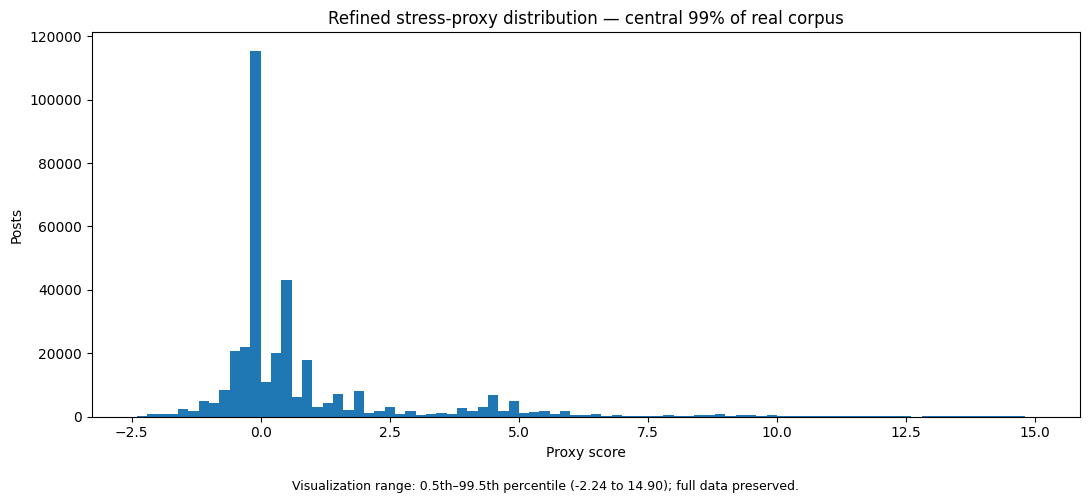

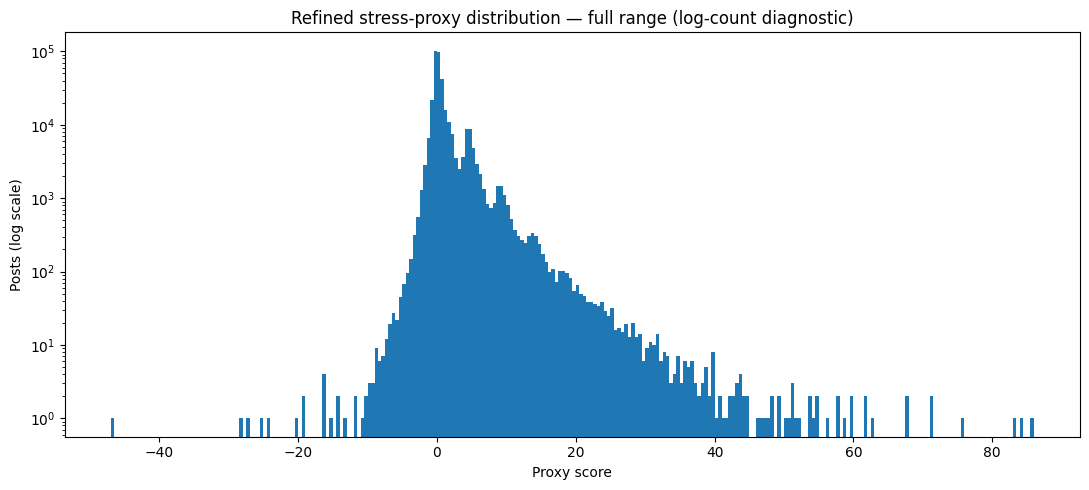

Saved: C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2\outputs\figures\stress_proxy_distribution.png
Saved: C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2\outputs\figures\stress_proxy_distribution_full_range_log.png
count    362017.000000
mean          0.977945
std           2.693823
min         -47.000000
0.5%         -2.240000
1%           -1.740000
5%           -0.780000
25%          -0.160000
50%           0.000000
75%           0.920000
95%           5.500000
99%          11.760000
99.5%        14.900000
max          86.000000
Name: stress_proxy, dtype: float64
Exact zero fraction: 0.133220263136814

Starter/reply audit (NOT used in the proxy formula):
             count      mean  median
is_starter                          
False       338479  0.837794    0.00
True         23538  2.993325    1.03


In [12]:
figdir = ROOT / "outputs" / "figures"
figdir.mkdir(parents=True, exist_ok=True)
proxy = pd.to_numeric(df["stress_proxy"], errors="coerce").dropna()

if DEMO_MODE:
    print("DEMO MODE: real stress-proxy figures are intentionally skipped.")
else:
    # The score is a weighted combination of integer counts, so it is discrete and strongly
    # concentrated near zero. A few legitimate extreme posts extend the full range to roughly
    # -47..86. Plotting thousands of Freedman-Diaconis bins over that full range makes the
    # central distribution look almost blank. For interpretation we therefore show the central
    # 99% of observations with a fixed 0.20-score bin width. This changes only the VIEW, not data.
    lo=float(proxy.quantile(0.005)); hi=float(proxy.quantile(0.995)); width=0.20
    lo_edge=np.floor(lo/width)*width; hi_edge=np.ceil(hi/width)*width
    bins=np.arange(lo_edge, hi_edge+width, width)
    central=proxy[(proxy>=lo)&(proxy<=hi)]

    plt.figure(figsize=(11,5))
    plt.hist(central, bins=bins)
    plt.title("Refined stress-proxy distribution — central 99% of real corpus")
    plt.xlabel("Proxy score")
    plt.ylabel("Posts")
    plt.figtext(0.5,0.01,f"Visualization range: 0.5th–99.5th percentile ({lo:.2f} to {hi:.2f}); full data preserved.",ha='center',fontsize=9)
    plt.tight_layout(rect=(0,0.04,1,1))
    main_fig=figdir/"stress_proxy_distribution.png"
    plt.savefig(main_fig,dpi=180)
    plt.show()

    # Full-range diagnostic uses log y so rare extreme scores remain visible without flattening
    # the main body of the distribution.
    plt.figure(figsize=(11,5))
    plt.hist(proxy, bins=np.arange(np.floor(proxy.min()), np.ceil(proxy.max())+0.5, 0.5))
    plt.yscale('log')
    plt.title("Refined stress-proxy distribution — full range (log-count diagnostic)")
    plt.xlabel("Proxy score")
    plt.ylabel("Posts (log scale)")
    plt.tight_layout()
    full_fig=figdir/"stress_proxy_distribution_full_range_log.png"
    plt.savefig(full_fig,dpi=180)
    plt.show()

    print("Saved:", main_fig)
    print("Saved:", full_fig)
    print(proxy.describe(percentiles=[0.005,0.01,0.05,0.25,0.5,0.75,0.95,0.99,0.995]))
    print("Exact zero fraction:", float((proxy==0).mean()))

print("\nStarter/reply audit (NOT used in the proxy formula):")
print(df.groupby("is_starter")["stress_proxy"].agg(["count","mean","median"]))


## 9. Stress-enriched annotation sampling

Random annotation would reproduce the natural imbalance of the forum and spend most annotation effort on calm/low-information replies.

Instead, the proxy is used for **purposeful sampling** from different score regions.

The default reconstruction uses low, middle, and high proxy bands so the initial labeled set contains enough variation to train a useful first model.

### Important statistical consequence

This is **not prevalence sampling**.

Because stressful-looking posts are deliberately oversampled, the fraction of High or Very-High labels in the resulting annotation/test data cannot be interpreted as:

> “the percentage of all Ninisite posts that are highly stressed.”

The purpose is model learning and evaluation across the stress range, not estimating population prevalence.

### Why keep `is_starter` in the exported sample?

It is useful for later auditing whether the sampling procedure accidentally selected almost only replies or starters.

It remains metadata, not a stress-proxy component.


In [13]:
sampled,sample_audit=sample_for_labeling(df,PCFG["sampling"],CFG["random_seed"],demo_mode=DEMO_MODE)
print(json.dumps(sample_audit,ensure_ascii=False,indent=2))
print("Starter/reply distribution in sample (audit only):")
print(sampled["is_starter"].value_counts(normalize=True,dropna=False))
display(sampled[["unique_post_id","content","is_starter","sampling_band","stress_proxy"]].head())

{
  "high_threshold": 5.5,
  "pool_sizes": {
    "low": 161303,
    "mid": 148291,
    "high": 18280
  },
  "sample_sizes": {
    "high": 900,
    "mid": 600,
    "low": 500
  }
}
Starter/reply distribution in sample (audit only):
is_starter
False    0.864
True     0.136
Name: proportion, dtype: float64


,unique_post_id,content,is_starter,sampling_band,stress_proxy
0,412966185,بخدا ادم اینطوری راحتتره البته که میرن باید تا...,False,high,7.34
1,382097411,سفیدش رو هم داشت,False,low,-0.08
2,340933161,کروموزوم های ۱۳ و ۱۴ و ۱۰ من مشکل دارن\nریسک ز...,False,high,7.04
3,401342521,بقیه قرصای ک خوردی چی بوده؟,False,mid,0.42
4,thread_12260668_starter,سلام دوستان خوبید، من دو سه روزه زایمان کردم د...,True,high,19.08


## 10. Annotation templates

The sampling stage outputs rows for independent AI-assisted annotation.

The project collected three scores:

- stress;
- anxiety;
- depression.

Only **stress** is the target used by the final project.

Anxiety and depression were collected to create a richer dataset and to help distinguish neighboring psychological constructs. They must not be fed into the stress model as predictor features, because doing so would use auxiliary labels that are unavailable for a new real-world post.

The annotation assistants are tools; the project team still owns the rubric, calibration, consensus logic, quality control, and final scientific interpretation.


In [14]:
labdir=ROOT/"data/labeling"; labdir.mkdir(parents=True,exist_ok=True)
for name in ["gpt","claude"]:
    ann=annotation_template(sampled,name)
    path=labdir/f"initial_labeling_{name}.csv"
    ann.to_csv(path,index=False,encoding="utf-8-sig")
    print("Saved",path,len(ann))
# generic combined candidate file
sampled.to_csv(labdir/"initial_labeling_candidates.csv",index=False,encoding="utf-8-sig")

Saved C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2\data\labeling\initial_labeling_gpt.csv 2000
Saved C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2\data\labeling\initial_labeling_claude.csv 2000


## 11. Save the proxy-enriched corpus

The output keeps both generations of lexical features and both proxy stages:

- temporary/seed positive and negative counts;
- broad learned positive and negative counts;
- initial proxy;
- refined proxy.

Keeping intermediate variables is useful for reproducibility and ablation studies. It lets us ask later:

> Did performance improve because of the learned lexicon, or would the seed features alone have been enough?

### System-designer takeaway

This phase is best summarized as:

**weak prior → transparent heuristic → contrastive corpus mining → human-filtered lexicon expansion → refined heuristic → informative annotation sampling.**

The goal was not to pretend the proxy was the final model. The goal was to use a cheap, interpretable signal to spend labeling effort intelligently.


In [15]:
out=ROOT/PCFG["output_csv"]; out.parent.mkdir(parents=True,exist_ok=True); df.to_csv(out,index=False,encoding="utf-8-sig")
required=["post_neg_count_temp","post_pos_count_temp","post_neg_count","post_pos_count","stress_proxy_initial","stress_proxy"]
assert all(c in df for c in required)
print("Saved",out,"rows",len(df))
print("PROXY / LABEL-SAMPLING NOTEBOOK COMPLETED SUCCESSFULLY")

Saved C:\Education\term6-private\DS\Project\MemberC_Early_Data_Pipeline_Project_Final_v2\MemberC_Early_Data_Pipeline_Project_Final_v2\data\processed\ninisite_cleaned_stress_proxy.csv rows 362017
PROXY / LABEL-SAMPLING NOTEBOOK COMPLETED SUCCESSFULLY
